## 케라스 모델을 만드는 여러 방법

- Sequential 모델 : 가장 시작하기 쉬운 API, 하나의 파이썬 리스트로 단순히 층을 쌓을 수만 있다.

- 함수형 API : 그래프 같은 모델 구조를 주로 다룬다. 사용성과 유연성 사이의 적절한 중간 지점에 해당된다.

- Model 서브클래싱 : 모든 것을 밑바닥부터 직접 만들 수 있는 저수준 방법

### Sequential 모델

- 가장 간단한 방법으로, Sequential 클래스를 사용해 만든다.

#### Sequential 클래스

In [1]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

2026-03-03 14:52:26.980667: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-03-03 14:52:26.980714: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2026-03-03 14:52:26.980731: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (BOOK-HU2G0S14U5): /proc/driver/nvidia/version does not exist
2026-03-03 14:52:26.982446: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


#### 점진적으로 Sequential 모델 만들기

In [2]:
model = keras.Sequential()
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

#### 가중치를 만들기 위해 모델 호출

In [3]:
model.build(input_shape=(None,3))
model.weights

[<tf.Variable 'dense_2/kernel:0' shape=(3, 64) dtype=float32, numpy=
 array([[-0.1419607 ,  0.28386015, -0.13645616,  0.07493514,  0.09426799,
         -0.1346682 ,  0.12717459,  0.26920897,  0.21659333, -0.01763558,
          0.20841312, -0.2792176 ,  0.09749889,  0.01503533, -0.01884648,
          0.00925583, -0.21818414,  0.13454726, -0.03630906,  0.06144869,
          0.17345017,  0.18149495,  0.26854253, -0.18406802, -0.24289925,
          0.22959715, -0.08073282, -0.04263437,  0.10626215,  0.06394613,
         -0.25822067, -0.03524742, -0.00940144, -0.24444236, -0.17937064,
          0.10563692,  0.09157079, -0.23339477, -0.28552678,  0.10518259,
         -0.2925236 ,  0.17520368,  0.09208006, -0.2881809 ,  0.1534422 ,
          0.16307661,  0.25116098, -0.21710965,  0.1440486 , -0.08297934,
         -0.1373189 , -0.26020285, -0.19971958,  0.01034737, -0.03903326,
         -0.21124054, -0.077498  ,  0.1170688 , -0.19908158, -0.24660711,
         -0.2461395 ,  0.08869693, -0.11281

In [4]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 64)                256       
                                                                 
 dense_3 (Dense)             (None, 10)                650       
                                                                 
Total params: 906
Trainable params: 906
Non-trainable params: 0
_________________________________________________________________


#### name 매개변수로 모델과 층에 이름 지정하기

In [5]:
model = keras.Sequential(name='my_model')
model.add(layers.Dense(64, activation='relu', name='dense_1'))
model.add(layers.Dense(10, activation='softmax', name='dense_2'))
model.build((None,3))
model.summary()

Model: "my_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 64)                256       
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 906
Trainable params: 906
Non-trainable params: 0
_________________________________________________________________


#### 모델의 입력크기를 미리 지정하기

In [6]:
model = keras.Sequential()
model.add(keras.Input(shape=(3,)))
model.add(layers.Dense(64, activation='relu'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 64)                256       
                                                                 
Total params: 256
Trainable params: 256
Non-trainable params: 0
_________________________________________________________________


In [7]:
model.add(layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 64)                256       
                                                                 
 dense_5 (Dense)             (None, 10)                650       
                                                                 
Total params: 906
Trainable params: 906
Non-trainable params: 0
_________________________________________________________________


### 함수형 API

- 다중 입력, 다중 출력, 또는 비선형적인 구조를 가진 모델에서 Sequential 모델은 적용이 제한적이다. 이런 경우에는 함수형 API를 사용해서 모델을 만들어 사용한다.

#### 2개의 Dense층을 가진 간단한 함수형 모델

In [8]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(3,), name='input_layer')
features = layers.Dense(64, activation='relu')(inputs)
outputs = layers.Dense(10, activation='softmax')(features)
model = keras.Model(inputs=inputs, outputs=outputs, name='my_model')
model.summary()

Model: "my_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   


 input_layer (InputLayer)    [(None, 3)]               0         
                                                                 
 dense_6 (Dense)             (None, 64)                256       
                                                                 
 dense_7 (Dense)             (None, 10)                650       
                                                                 
Total params: 906
Trainable params: 906
Non-trainable params: 0
_________________________________________________________________


#### 다중 입력, 다중 출력 함수형 모델

In [9]:
vocabulary_size = 10000
num_tags = 100
num_departments = 4

title = keras.Input(shape=(vocabulary_size,), name='title')
text_body = keras.Input(shape=(vocabulary_size,), name='text_body')
tags = keras.Input(shape=(num_tags,), name='tags')

features = layers.Concatenate()([title, text_body, tags])
features = layers.Dense(64, activation='relu')(features)

priority = layers.Dense(1, activation='sigmoid', name='priority')(features)
department = layers.Dense(
    num_departments, activation='softmax', name='department'
)(features)

model = keras.Model(inputs=[title, text_body, tags], outputs=[priority, department])

In [10]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 title (InputLayer)             [(None, 10000)]      0           []                               
                                                                                                  
 text_body (InputLayer)         [(None, 10000)]      0           []                               
                                                                                                  
 tags (InputLayer)              [(None, 100)]        0           []                               
                                                                                                  
 concatenate (Concatenate)      (None, 20100)        0           ['title[0][0]',                  
                                                                  'text_body[0][0]',          

#### 입력과 타깃 배열 리스트를 전달하여 모델 훈련하기

In [11]:
import numpy as np

num_samples = 1280

title_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
text_body_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
tags_data = np.random.randint(0, 2, size=(num_samples, num_tags))

priority_data = np.random.random(size=(num_samples, 1))
department_data = np.random.randint(0,2, size=(num_samples, num_departments))

model.compile(optimizer='rmsprop',
              loss=['binary_crossentropy', 'categorical_crossentropy'],
              metrics=[['mean_absolute_error'],['accuracy']])
model.fit(
    [title_data, text_body_data, tags_data],
    [priority_data, department_data],
    epochs=1
)

model.evaluate([title_data, text_body_data, tags_data], [priority_data, department_data])
priority_preds, department_preds = model.predict([title_data, text_body_data, tags_data])

40/40 [==============================] - 0s 4ms/step - loss: 18.5637 - priority_loss: 6.8171 - department_loss: 11.7466 - priority_mean_absolute_error: 0.4953 - department_accuracy: 0.2531


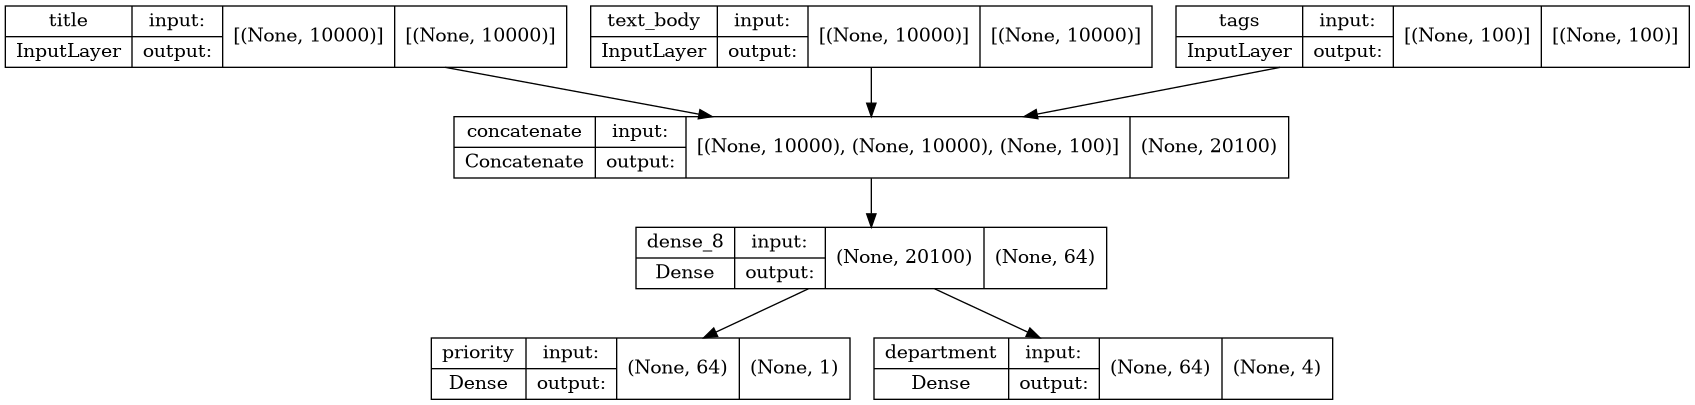

In [12]:
keras.utils.plot_model(model, 'ticket_classifier.png', show_shapes=True)

#### 함수형 모델에 있는 층의 입력과 출력을 출력하기

In [13]:
print(model.layers)
print(model.layers[3].input)
print(model.layers[3].output)

[<keras.engine.input_layer.InputLayer object at 0x7ccacbb19d90>, <keras.engine.input_layer.InputLayer object at 0x7ccacbb19af0>, <keras.engine.input_layer.InputLayer object at 0x7ccacbb19dc0>, <keras.layers.merge.Concatenate object at 0x7ccacbb29160>, <keras.layers.core.dense.Dense object at 0x7ccacbb1ca60>, <keras.layers.core.dense.Dense object at 0x7ccb32c37a60>, <keras.layers.core.dense.Dense object at 0x7ccacbb0a3d0>]
[<KerasTensor: shape=(None, 10000) dtype=float32 (created by layer 'title')>, <KerasTensor: shape=(None, 10000) dtype=float32 (created by layer 'text_body')>, <KerasTensor: shape=(None, 100) dtype=float32 (created by layer 'tags')>]
KerasTensor(type_spec=TensorSpec(shape=(None, 20100), dtype=tf.float32, name=None), name='concatenate/concat:0', description="created by layer 'concatenate'")


#### 중간층의 출력을 재사용해서 새로운 모델 만들기

In [14]:
features = model.layers[4].output
difficulty = layers.Dense(3, activation='softmax', name='difficulty')(features)
new_model = keras.Model(
    inputs = [title, text_body, tags],
    outputs = [priority, department, difficulty]
)

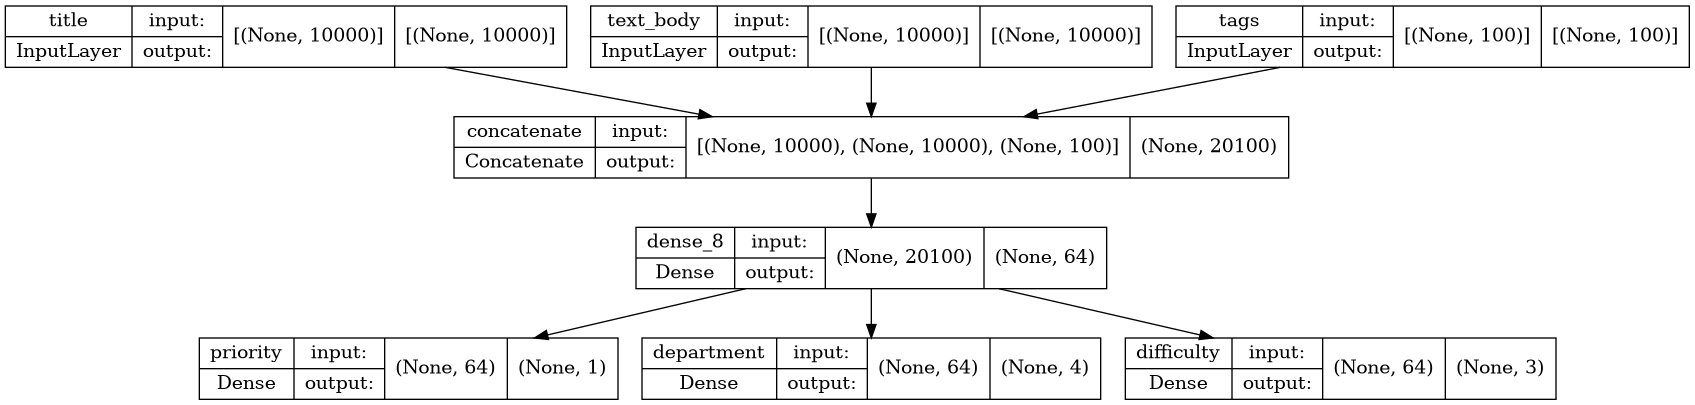

In [15]:
keras.utils.plot_model(new_model, 'ticket_classifier_with_difficulty.png', show_shapes=True)

### Model 서브클래싱

- 모델 구축 패턴 중 가장 고급 방법이다. 

- __ init __() 메서드에서 모델이 사용할 층을 정의한다.

- call() 메서드에서 앞서 만든 층을 사용하여 모델의 정방향 패스를 정의한다.

- 서브클래스의 객체를 만들고 데이터와 함께 호출하여 가중치를 만든다.

#### 간단한 서브클래싱 모델

In [16]:
from tensorflow import keras
from tensorflow.keras import layers

In [17]:
class CustomerTicketModel(keras.Model):
    def __init__(self, num_departments):
        super().__init__()
        self.concat_layer = layers.Concatenate()
        self.mixing_layer = layers.Dense(64, activation='relu')
        self.priority_scorer = layers.Dense(1, activation='sigmoid')
        self.department_classifier = layers.Dense(
            num_departments, activation='softmax'
        )
    def call(self,inputs):
        title = inputs['title']
        text_body = inputs['text_body']
        tags = inputs['tags']
        features = self.concat_layer([title, text_body, tags])
        features = self.mixing_layer(features)
        priority = self.priority_scorer(features)
        department = self.department_classifier(features)
        return priority, department

In [18]:
import numpy as np

num_samples = 1280
vocabulary_size = 10000
num_tags = 4
num_departments = 4

title_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
text_body_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
tags_data = np.random.randint(0, 2, size=(num_samples, num_tags))

In [19]:
model = CustomerTicketModel(num_departments=num_departments)
priority, department = model(
    {'title': title_data, 'text_body': text_body_data, 'tags': tags_data}
)

In [20]:
model.compile(optimizer='rmsprop',
              loss=['mean_squared_error', 'categorical_crossentropy'],
              metrics=[['mean_absolute_error'], ['accuracy']])

model.fit({'title': title_data, 'text_body': text_body_data, 'tags': tags_data},
          [priority, department],
          epochs=1)

model.evaluate({'title': title_data, 'text_body': text_body_data, 'tags': tags_data},
               [priority, department])

priority_preds, department_preds = model.predict({'title': title_data, 'text_body': text_body_data, 'tags': tags_data})

40/40 [==============================] - 0s 4ms/step - loss: 3.7792 - output_1_loss: 0.2118 - output_2_loss: 3.5674 - output_1_mean_absolute_error: 0.4406 - output_2_accuracy: 0.0391


### 여러 방식을 혼합하여 사용하기

- 케라스 API로 만든 모델은 Sequential 모델, 함수형 모델 또는 밑바닥부터 만든 서브클래싱 모델인지에 상관없이 부드럽게 서로 상호 운영할 수 있다.

#### 서브클래싱한 모델을 포함하는 함수형 모델 만들기

In [21]:
class Classifier(keras.Model):
    def __init__(self, num_classes=2):
        super().__init__()
        if num_classes == 2:
            num_units = 1
            activation = 'sigmoid'
        else:
            num_units = num_classes
            activation = 'softmax'
        self.dense = layers.Dense(num_units, activation=activation)

    def call(self, inputs):
        return self.dense(inputs)
    
inputs = keras.Input(shape=(3,))
features = layers.Dense(64, activation='relu')(inputs)
outputs = Classifier(num_classes=10)(features)
model = keras.Model(inputs=inputs, outputs=outputs)

#### 함수형 모델을 포함하는 서브클래싱 모델 만들기

In [22]:
inputs = keras.Input(shape=(64,))
outputs = layers.Dense(1, activation='sigmoid')(inputs)
binary_classifier = keras.Model(inputs=inputs, outputs=outputs)

class MyModel(keras.Model):
    def __init__(self, num_classes=2):
        super().__init__()
        self.dense = layers.Dense(64, activation='relu')
        self.classifier = binary_classifier

    def call(self, inputs):
        features = self.dense(inputs)
        return self.classifier(features)
    
model = MyModel()

#### 표준 워크플로: compile(), fit(), evaluate(), predict()

In [23]:
from tensorflow.keras.datasets import mnist

def get_mnist_model():
    inputs = keras.Input(shape=(28*28),)
    features = layers.Dense(512, activation='relu')(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation='softmax')(features)
    model = keras.Model(inputs, outputs)
    return model

(images, labels), (test_images, test_labels) = mnist.load_data()
images = images.reshape((60000, 28*28)).astype('float32') / 255
test_images = test_images.reshape((10000, 28*28)).astype('float32') / 255
train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

model = get_mnist_model()
model.compile(optimizer='rmsprop', # 옵티마이저, 최소화할 손실 함수, 모니터링할 지표를 지정하여 모델을 컴파일한다.
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images, train_labels, # fit() 메서드를 사용해서 모델을 훈련한다. 본 적 없는 데이터에 대한 성능을 모니터링하기 위해 검증 데이터를 함께 제공한다.
          epochs=3,
          validation_data=(val_images, val_labels))
test_metrics = model.evaluate(test_images, test_labels) # evaluate() 메서드를 사용해서 모델의 성능을 평가한다.
predictions = model.predict(test_images) # predict() 메서드를 사용해서 모델을 사용하여 새로운 데이터에 대한 예측을 생성한다.

Epoch 1/3
1563/1563 [==============================] - 8s 5ms/step - loss: 0.2956 - accuracy: 0.9134 - val_loss: 0.1511 - val_accuracy: 0.9594
Epoch 2/3
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1662 - accuracy: 0.9531 - val_loss: 0.1242 - val_accuracy: 0.9659
Epoch 3/3
313/313 [==============================] - 0s 1ms/step - loss: 0.1025 - accuracy: 0.9732


#### Callback 클래스를 상속하여 사용자 정의 콜백 만들기

Epoch 1/10
1563/1563 [==============================] - 6s 3ms/step - loss: 0.2940 - accuracy: 0.9132 - val_loss: 0.1548 - val_accuracy: 0.9564
Epoch 2/10
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1648 - accuracy: 0.9540 - val_loss: 0.1264 - val_accuracy: 0.9671
Epoch 3/10
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1401 - accuracy: 0.9633 - val_loss: 0.1126 - val_accuracy: 0.9699
Epoch 4/10
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1293 - accuracy: 0.9677 - val_loss: 0.1102 - val_accuracy: 0.9715
Epoch 5/10
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1169 - accuracy: 0.9711 - val_loss: 0.1182 - val_accuracy: 0.9760
Epoch 6/10
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1105 - accuracy: 0.9734 - val_loss: 0.1147 - val_accuracy: 0.9745
Epoch 7/10
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1073 - accuracy: 0.9747 - val_loss: 0.1121 - val_accuracy:

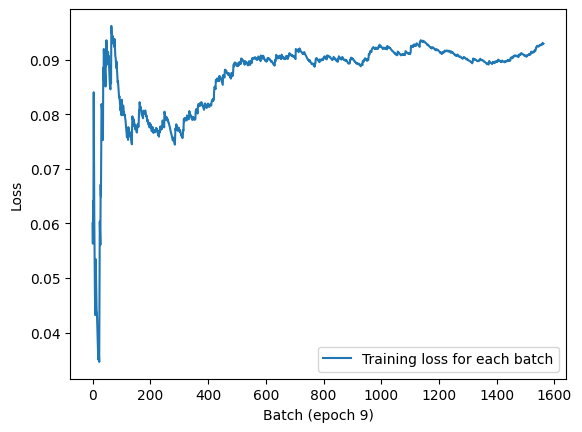

In [24]:
from matplotlib import pyplot as plt

class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs):
        self.per_batch_losses = []
    def on_batch_end(self, batch, logs):
        self.per_batch_losses.append(logs.get('loss'))
    def on_epoch_end(self, epoch, logs):
        plt.clf()
        plt.plot(range(len(self.per_batch_losses)), self.per_batch_losses,
                 label='Training loss for each batch')
        plt.xlabel(f'Batch (epoch {epoch})')
        plt.ylabel('Loss')
        plt.legend()
        plt.savefig(f'plot_at_epoch_{epoch}')
        self.per_batch_losses = []

model = get_mnist_model()
model.compile(optimizer='rmsprop',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
model.fit(train_images, train_labels,
              epochs=10,
              callbacks=[LossHistory()],
              validation_data=(val_images, val_labels))

### 사용자 정의 훈련, 평가 루프

#### 단계별 훈련 루프 작성하기 : 훈련 스텝 함수

In [26]:
model = get_mnist_model()

## Notes

##### 서브클래싱된 모델이 지원하지 않는 것

- 서브클래싱된 모델에서는 모델 로직을 많이 책임져야 하며 잠재적인 오류 가능성이 훨씬 커서, 겨과적으로 더 많은 디버깅 작업을 해야 한다.

- 함수형 모델은 명시적인 데이터 구조인 층의 그래프이므로 출력하고 조사하고 수정할 수 있다. 서브클래싱 모델은 한 덩어리의 바이트코드이다. 원시코드가 담긴 call() 메서드를 가진 파이썬 클래스이다. 

- 예를 들어, 층이 서로 연결되는 방식이 call() 메서드 안에 감추어지기 때문에 이 정보를 활용할 수 없다. summary() 메서드가 층의 연결 구조를 츨력할 수 없고 plot_model() 함수로 모델의 구조를 그래프로 그릴 수 없다.

##### 작업에 적합한 도구 사용하기

- 케라스 모델 구축을 위해 가장 단순한 워크플로인 Sequential 모델부터 가장 고급인 Model 서브클래싱까지 다양한 워크플로가 있다.

- 일반적으로, 함수형 API가 쉬운 사용성과 유연성 사이에 적절한 절충점이다. 층 연결 구조를 활용하여 모델 출력이나 특성 추출과 같은 용도에 잘 맞다. 함수형 API를 사용할 수 있다면, 즉 모델을 층의 유향 비순환 그래프로 표현할 수 있다면 Model 서브클래싱보다 이 방식을 사용하는 것이 낫다.

##### ModelCheckpoint와 EarlyStopping 콜백

- 모델을 훈련할 때는 미리 예상할 수 없는 것이 많다. 특히 최적의 검증 손실을 얻기 위해 얼마나 많은 에포크가 필요한지 알지 못한다. 좋은 처리 방법은 검증 손실이 더 이상 향상되지 않을 때 훈련을 멈추는 것이고, EarlyStopping 콜백을 사용하여 이를 구현할 수 있다. EarlyStopping 콜백은 정해진 에포크 동안 모니터링 지표가 향상되지 않을 때 훈련을 중지한다. 일반적으로 이 콜백은 훈련하는 동안 모델을 계속 저장해주는 ModelCheckpoint 콜백과 함께 사용한다.

##### 사용자 정의 훈련, 평가루프

- 내장된 fit() 워크플로는 지도학습에만 초점이 맞추어져 있다.
```
지도학습은 입력 데이터와 이에 연관된 레이블(타깃)을 가진 학습을 의미한다.
```
- 생성학습, 강화학습, 자기지도 학습에는 명시적인 타깃이 없는 경우가 있고, 이런 경우에는 새로운 기능을 추가해줘야 한다.
```
<전형적인 훈련 루프>
1. 현재 배치 데이터에 대한 손실 값을 얻기 위해 그레이디언트 테이프 안에서 정방향 패스를 실행한다.
2. 모델 가중치에 대한 손실의 그레이디언트를 계산한다.
3. 현재 배치 데이터에 대한 손실 값을 낮추는 방향으로 모델 가중치를 업데이트한다.
```

##### 훈련 vs. 추론

- 저수준 훈련 루프에서는 predictions = model(inputs)를 통해, 정방향을 수행하고 gradients = tape.gradient(loss, model.weights)를 통해 그레이디언트 테이프로 계산한 그레이디언트를 추출한다.

- Dropout 층과 같은 일부 케라스 층은 훈련과 추론에서 동작이 다르다. 이런 층은 call() 메서드에 training 불리언 매개변수를 제공한다.
```
dropout(inputs, training=True) => 이전 층의 활성화 출력값을 일부 랜덤하게 제외한다. 마스크를 매 forward마다 새로 뽑고, 일부 활성화를 0으로 하고 스케일링을 적용한다.
dropout(inputs, training=False) => 아무런 일을 수행하지 않는다.
```

- 훈련 가능한 가중치 => Dense 층의 커널과 편향처럼 모델의 손실을 최소화하기 위해 역전파로 업데이트된다.

- 훈련되지 않는 가중치 => 해당층의 정방향 패스동안 업데이트가 일어난다. 예를 들어, 얼마나 많은 배치를 처리했는지 카운트 하는 사용자 정의층이 필요할 경우, 이 정보는 훈련되지 않는 가중치에 저장하고 배치마다 값을 1씩 증가시킨다.